#### Student Name: Kevin Cao
#### Student ID: A18315089

## Speech Formants with Linear Predictive Coding, Vocoder (Mister Blue Sky)

Instructions: 

* This notebook is an interactive assignment; please read and follow the instructions in each cell. 

* Cells that require your input (in the form of code or written response) will have 'Question #' above.

* After completing the assignment, please submit this notebook and its pdf printout and all sound files. 

## Speech Formants and LPC

In this section, you will synthesize vowel sounds, and investigate the frequencies in vowels from your own voice. 

mystery_1
mystery_2
mystery_3


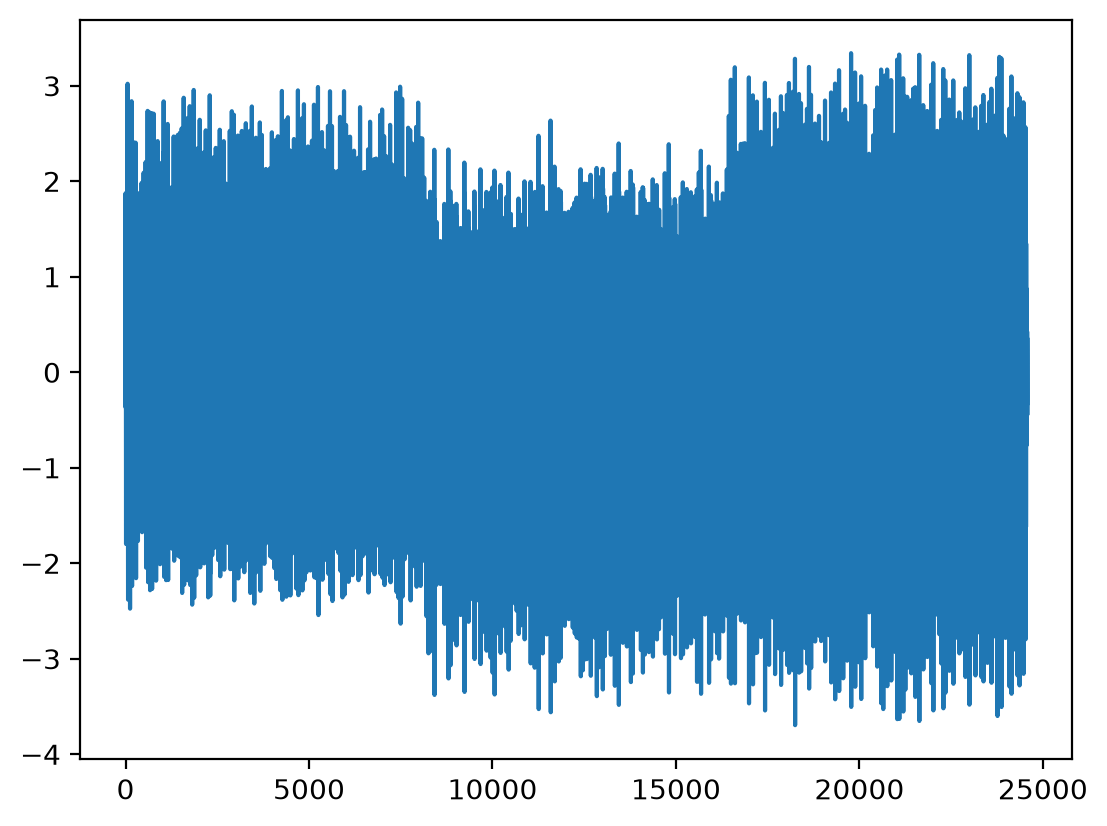

In [170]:
import numpy as np
import pandas as pd
from collections import Counter
from numpy.random import multinomial as randm
from numpy import where
import scipy.signal as si
import matplotlib.pyplot as plt
from matplotlib import patches
import IPython.display as ipd
import librosa
import scipy
import librosa.display as ld
from scipy.io import wavfile as wavfile 
import copy


Fdict = {
    'mystery_1':[[328, 2208, 2885],[27,80,575]],
    'mystery_2':[[504, 868, 2654],[62,   108,  299]],
    'mystery_3':[[700, 1220, 2600],[130,   70,  160]]
    } # Formant frequencies in Hz

def excitation(f0, jitt, dur, nharm=None, unvoiced=False, sample_rate=None):
    sample_rate = fs if sample_rate is None else sample_rate
    nsamps = int(round(sample_rate * dur))
    assert nsamps > 0

    if unvoiced:
        sig = np.random.normal(size=nsamps)
    else:
        if nharm is None:
            nharm = int((sample_rate / 2) // f0)
        n = np.arange(nsamps)
        phase_jitter = np.random.uniform(size=nsamps) * 2 * np.pi
        omega0 = 2 * np.pi * f0 / sample_rate
        harmonics = np.arange(1, nharm)[:, None]
        sig = np.cos(
            harmonics * omega0 * n + jitt * phase_jitter
        ).sum(axis=0)

    peak = np.max(np.abs(sig))
    assert peak > 0
    return sig / peak

def voca(sig, F, Fb, sample_rate=None):
    sample_rate = fs if sample_rate is None else sample_rate
    F = np.asarray(F, dtype=float)
    Fb = np.asarray(Fb, dtype=float)

    radii = np.exp(-np.pi * Fb / sample_rate)
    angles = 2 * np.pi * F / sample_rate
    poles = radii * np.exp(1j * angles)
    B, A = si.zpk2tf(
        [],
        np.concatenate([poles, np.conj(poles)]),
        1.0,
    )

    speech = si.lfilter(B, A, np.asarray(sig, dtype=float))
    scale = np.std(speech)
    assert scale > 0
    return speech / scale, B, A

fs = 8192 # 22050  % Sampling rate in Hz ("telephone quality" for speed)

vowels = list(Fdict.keys())
f0 = 150 # Pitch in Hz
dur = 1 #one second in duration
ji = 0.1 #0.1
ex = excitation(f0,ji,dur)

text = ['mystery_1','mystery_2','mystery_3']

speech = np.zeros(1)
for t in text:
    F = np.array(Fdict[t][0])
    Fb = np.array(Fdict[t][1])
    print(t)

    vow,B,A = voca(ex,F,Fb)
    speech = np.concatenate((speech,vow))

speech = speech/np.std(speech)
plt.plot(speech)

In [171]:
ipd.Audio(speech, rate=fs) 

##### Question 1 (10 points)

Based on the audio output, what vowels were synthesized as mystery_1, mystery_2, and mystery_3? 
Please specify using a word; for example, if you heard an 'oo' sound as in 'hoot', you may answer with the word "hoot". 

mystery_1:heed

mystery_2:hoot

mystery_3:had

Now we will examine just one vowel in greater detail. 
Select one mystery vowel to analyze below: 

mystery_1


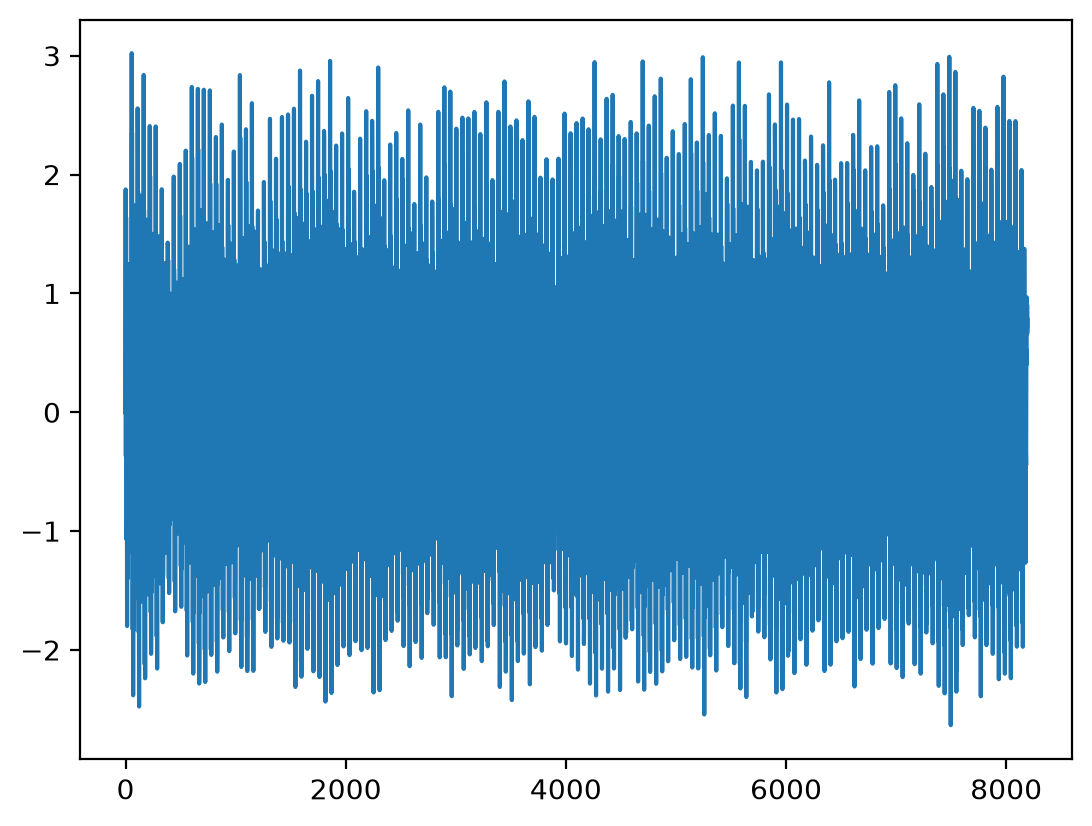

In [172]:
%matplotlib inline  

### Modify the line below:
text = ['mystery_1']

speech = np.zeros(1)
for t in text:
    F = np.array(Fdict[t][0])
    Fb = np.array(Fdict[t][1])
    print(t)

    vow,B,A = voca(ex,F,Fb)
    speech = np.concatenate((speech,vow))

speech = speech/np.std(speech)
plt.plot(speech)

/var/folders/7n/pwv7lvkj7h191ygl7jjl8hpr0000gn/T/ipykernel_19239/3988430760.py:2: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(speech, 1024)


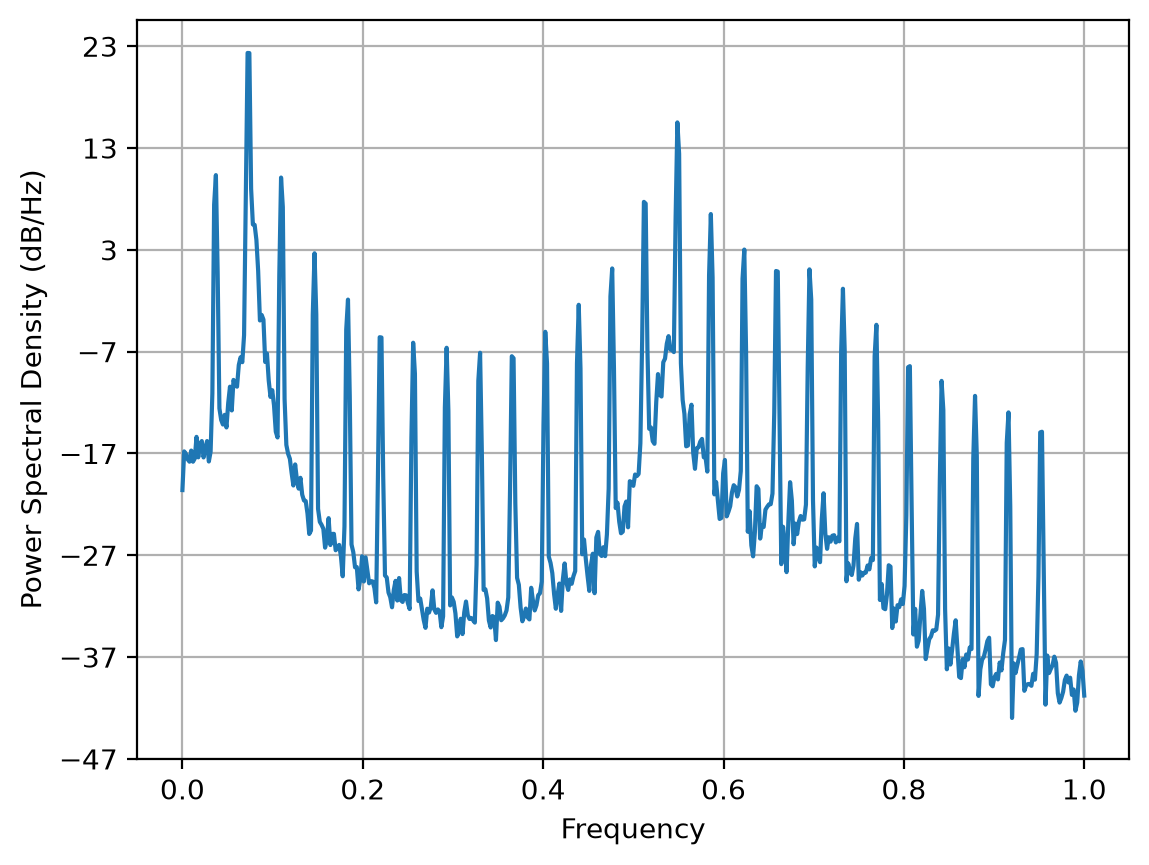

In [173]:
# Plot the power spectral density (PSD)
plt.psd(speech, 1024)
plt.show()

[ 1.         -0.72332167  0.56170716 -1.29644172  0.45993023 -0.2825455
  0.64683465 -0.14773568  0.11798198 -0.02376574  0.05906165]


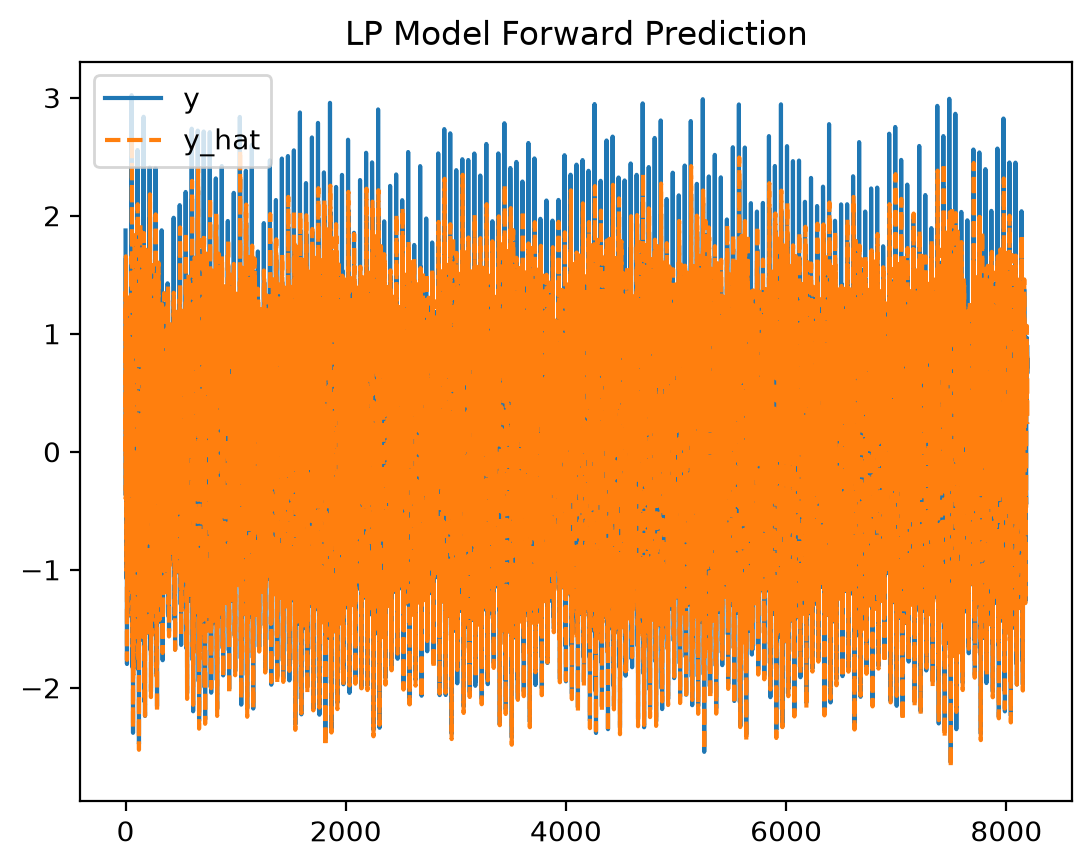

In [174]:
lpc_order = 10
s = speech

a = librosa.core.lpc(s, order=lpc_order)
print(a)
s_hat = scipy.signal.lfilter([0] + -1*a[1:], [1], s)
s_err = s[1:] - s_hat[:-1]
plt.plot(s[1:])
plt.plot(s_hat[:-1], linestyle='--')
plt.legend(['y', 'y_hat'])
plt.title('LP Model Forward Prediction')
plt.show()

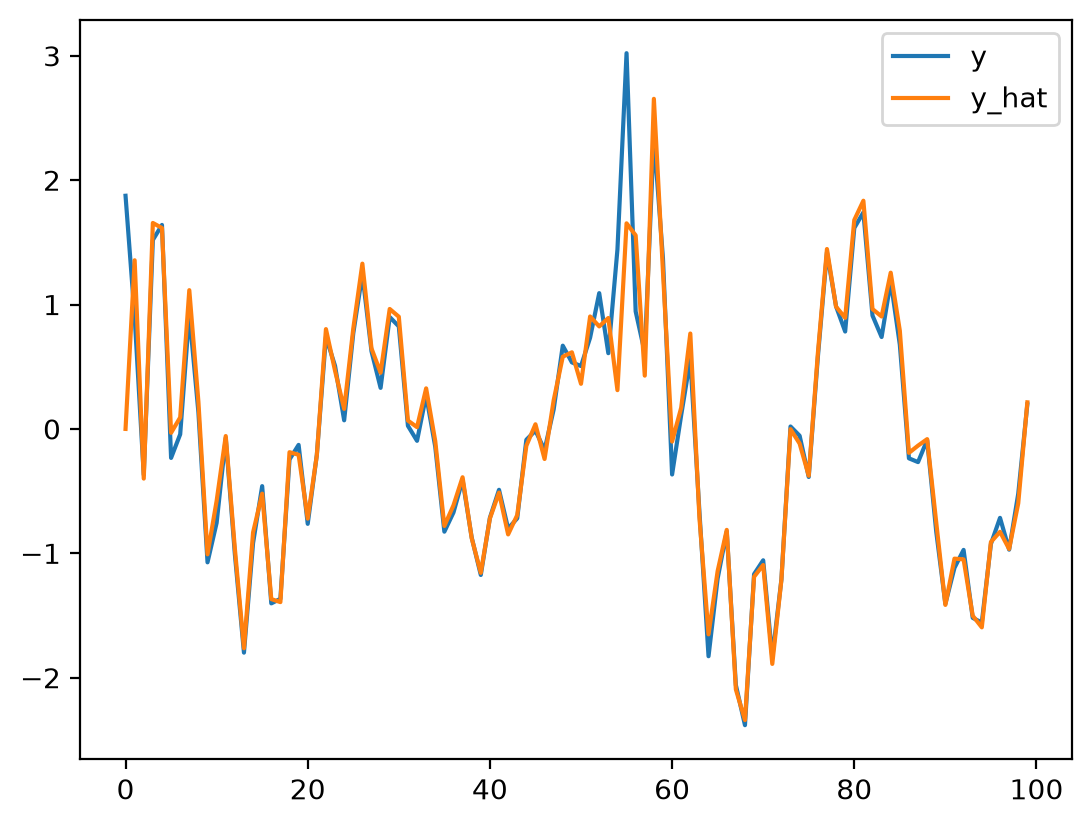

In [175]:
plt.plot(s[1:101])
plt.plot(s_hat[:100])
plt.legend(['y', 'y_hat'])
plt.show()

##### Question 2 (10 points)

What is being visualized as y and y_hat on the above plot?

In the LP Model Forward Prediction plots, y represents the original time‑domain samples of the synthesized “heed” vowel (mystery_1), and y_hat represents the LPC model’s one‑step‑ahead prediction of those samples. Over the full signal, y_hat almost completely overlaps y, and in the zoomed‑in view of the first 100 samples the prediction closely follows every oscillation of the waveform. This shows that the linear prediction model provides a very accurate autoregressive approximation of the vowel’s waveform for this choice of LPC order.

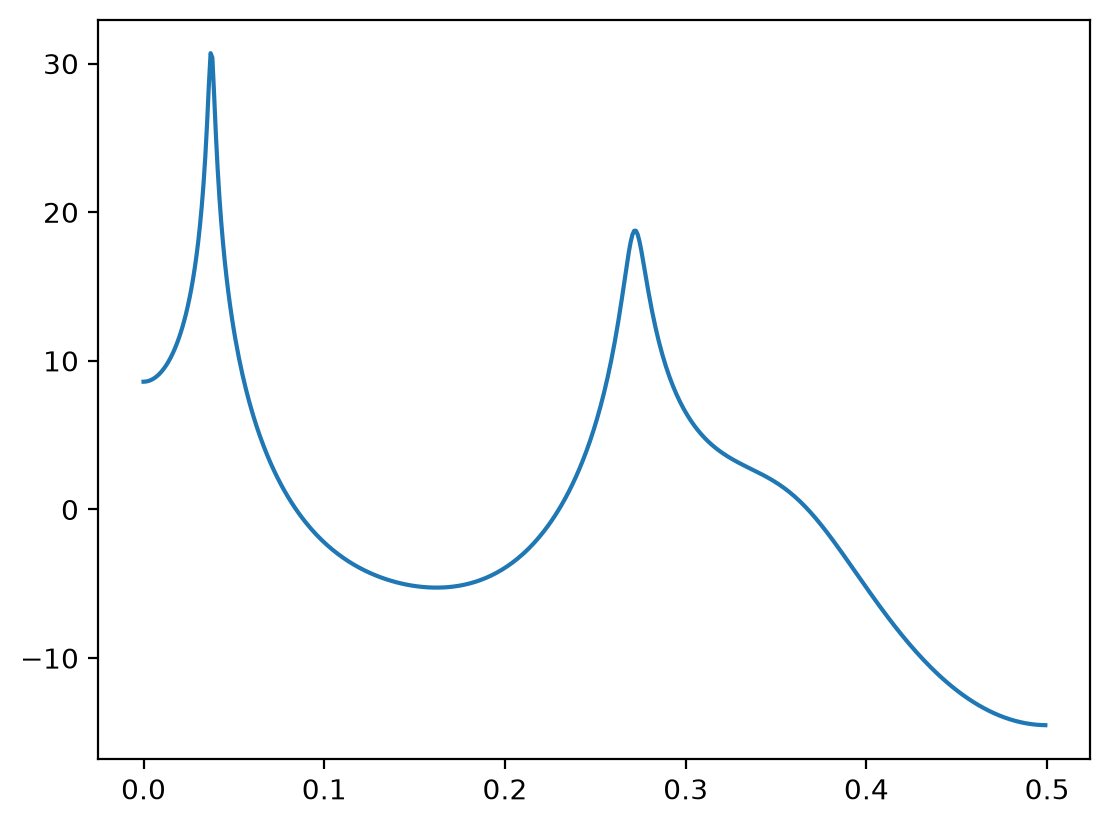

In [176]:
w,h = si.freqz(b=1,a = a, fs=1)
plt.plot(w,20*np.log10(h))

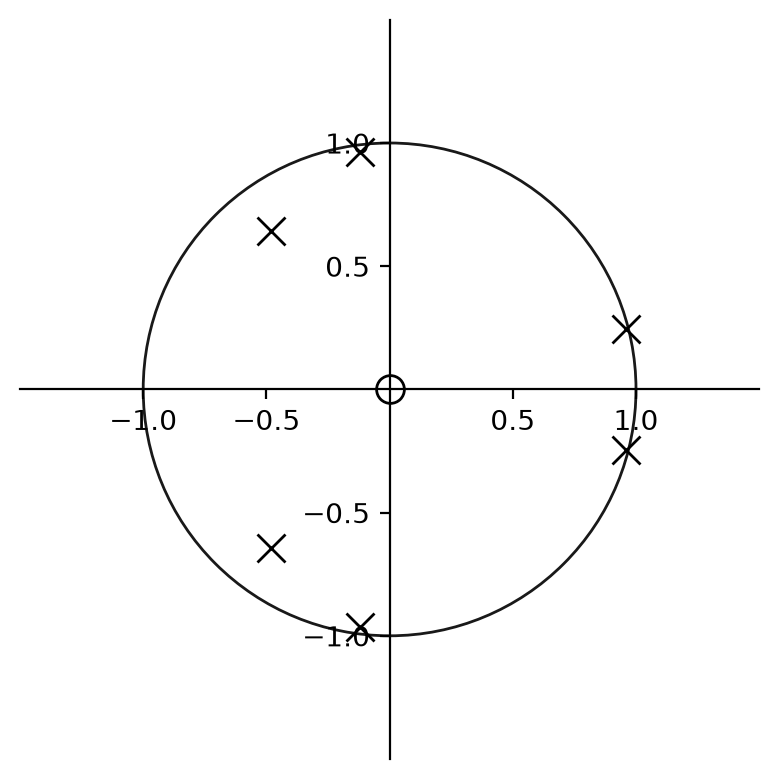

In [177]:
z,p,k = si.tf2zpk(B,A)
    
unit_circle = patches.Circle((0,0), radius=1, fill=False, color='black', ls='solid', alpha=0.9)
ax = plt.subplot(111)
ax.add_patch(unit_circle)
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)    
    
plt.plot(z.real, z.imag, 'ko', fillstyle='none', ms = 10)
plt.plot(p.real, p.imag, 'kx', fillstyle='none', ms = 10)

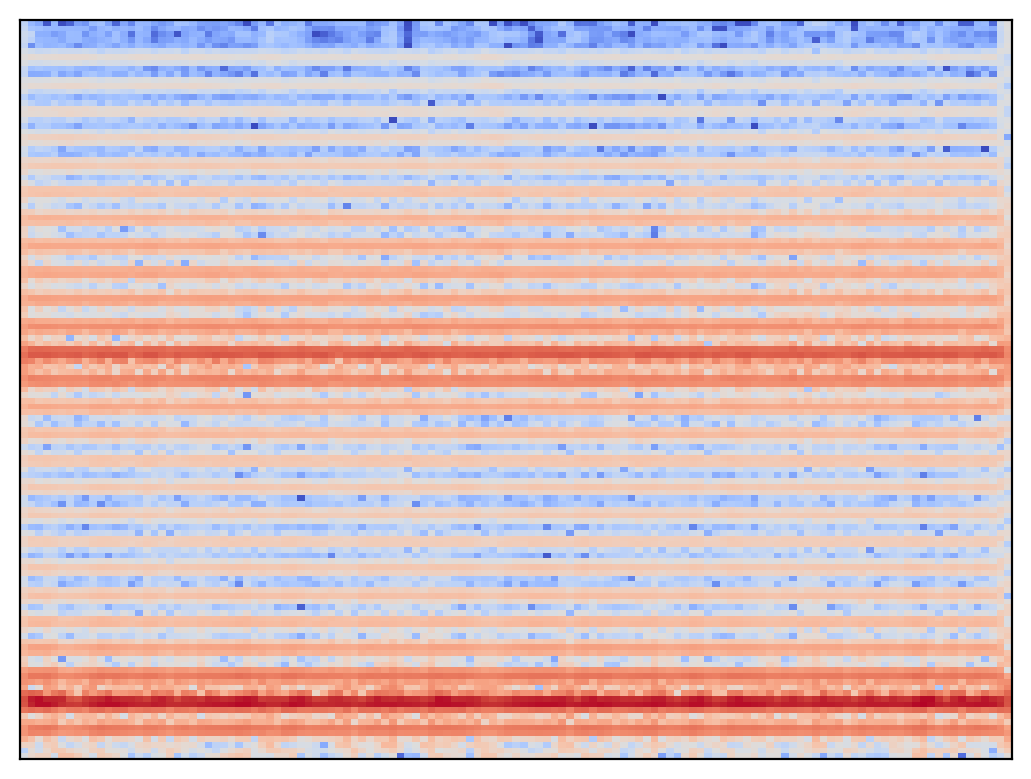

In [178]:
D = np.abs(librosa.stft(s,n_fft=256,hop_length = 64))
ld.specshow(librosa.amplitude_to_db(D))

##### Question 3 (20 points)

Record yourself speaking the same vowel sound you analyzed above. 
Graph the power spectral density (PSD) of your recording alongside the PSD of the synthetic signal. 

/var/folders/7n/pwv7lvkj7h191ygl7jjl8hpr0000gn/T/ipykernel_19239/2493781057.py:15: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(speech, 1024, label="synthetic")
/var/folders/7n/pwv7lvkj7h191ygl7jjl8hpr0000gn/T/ipykernel_19239/2493781057.py:16: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(rec, 1024, label="recorded")


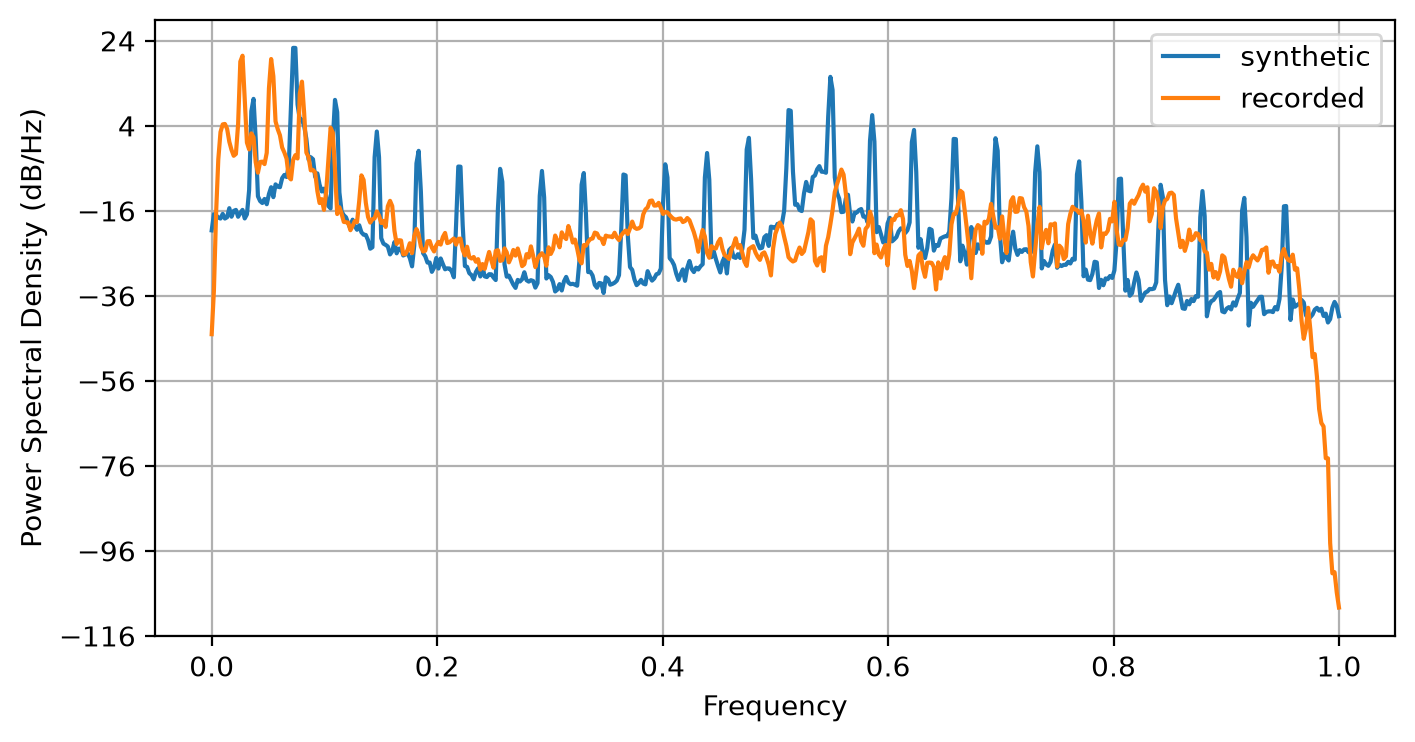

In [179]:
### Your Code Here
sr, rec = wavfile.read("heed.wav")

if rec.ndim > 1:
    rec = rec.mean(axis=1)

rec = rec.astype(float)
rec = rec / np.std(rec)

if sr != fs:
    rec = librosa.resample(rec, orig_sr=sr, target_sr=fs)
    sr = fs

plt.figure(figsize=(8,4))
plt.psd(speech, 1024, label="synthetic")
plt.psd(rec, 1024, label="recorded")
plt.legend()
plt.show()


##### Question 4 (10 points)

How does the power spectral density of your recorded signal compare to the LPC spectrum? 

The PSD of my recorded “heed” vowel and the PSD of the synthetic vowel have a broadly similar spectral envelope: both show stronger energy at low frequencies that gradually rolls off toward higher frequencies, and both have enhanced bands in roughly the same formant regions. However, the synthetic PSD has very sharp, regularly spaced harmonic peaks coming from the idealized periodic excitation, while the recorded PSD is smoother and more irregular, with less pronounced harmonics and more noise. This reflects the fact that the LPC‑based synthetic signal is generated from a clean excitation passed through a fixed vocal‑tract filter, whereas my recording includes natural pitch jitter, breath noise, and recording artifacts, so its spectrum is a noisier, less perfectly harmonic version of the same underlying vowel shape.

# Simple Singing Vocoder

In this section we will use a spoken sound to process an excitation that plays a melody. In music such an effect is known as vocoding and it is used to produce a talking musical instrument. 

In [ ]:
def lpc_to_formants(lpc, sr):
    roots = np.roots(lpc)
    roots = roots[np.imag(roots) > 0]
    roots = np.where(
        np.abs(roots) > 1,
        1 / np.conj(roots),
        roots,
    )

    freqs = np.angle(roots) * sr / (2 * np.pi)
    bws = -sr * np.log(np.abs(roots)) / np.pi

    valid = (
        np.isfinite(freqs)
        & np.isfinite(bws)
        & (freqs > 0)
        & (freqs < sr / 2)
        & (bws > 0)
    )
    order = np.argsort(freqs[valid])
    return freqs[valid][order], bws[valid][order]
    """Convert LPC to formants    
    """
        
    # extract roots, get angle and radius
    roots = np.roots(lpc)
    
    pos_roots = roots[np.imag(roots)>=0]
    if len(pos_roots)<len(roots)//2:
        pos_roots = list(pos_roots) + [0] * (len(roots)//2 - len(pos_roots))
    if len(pos_roots)>len(roots)//2:
        pos_roots = pos_roots[:len(roots)//2]
    
    w = np.angle(pos_roots)
    a = np.abs(pos_roots)
    
    order = np.argsort(w)
    w = w[order]
    a = a[order]
    
    freqs = w * (sr/(2*np.pi))
    bws =  -0.5 * (sr/(2*np.pi)) * np.log(a)    
    
    # exclude DC and sr/2 frequencies
    return freqs, bws

##### Questioon 5 [10 points] 

Record yourself speaking slowly the sentence "Mister Blue Sky". Plot a spectrogram of the speech sound.

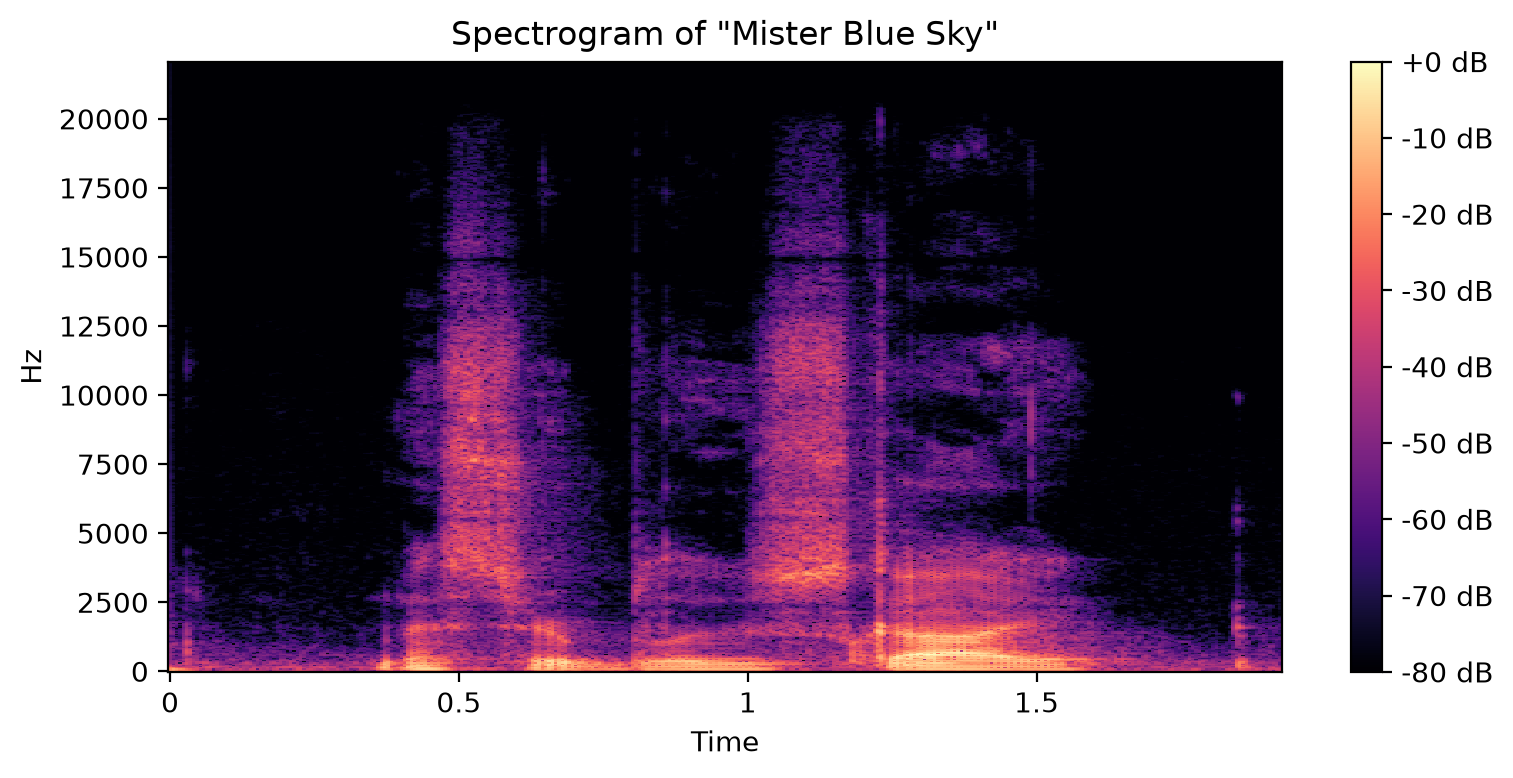

In [181]:
# Your code here
sr, wave = wavfile.read("Speech.wav")

if wave.ndim > 1:
    wave = wave.mean(axis=1)

wave = wave.astype(float)
wave = wave / (np.max(np.abs(wave)) + 1e-12)

D = np.abs(librosa.stft(wave, n_fft=1024, hop_length=256))

plt.figure(figsize=(8,4))
ld.specshow(librosa.amplitude_to_db(D, ref=np.max), sr=sr, hop_length=256, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of "Mister Blue Sky"')
plt.tight_layout()
plt.show()

##### Question 6 [30 points]

In this question we will create a song based on the spoken sentence you recorded. You will choose the melody by creating a sequence of pitches that change slowly over time.
Write a function that does the following:

1. Divide the speech signal into short slices (frames) of 512 samples with 50% overlap
2. For each speech segment compute formants by converting lpc_to_formants (F,Fb)
3. Choose a pitch (f0) for each segment
4. Using the voca function, create a speech sound (vow) from an excitation (ex) with that pitch
4. Overlap and add the sound segments with cross-fade window to create one long sound file 

You are free to alter the durations of the segments and choice of notes for the melody. 
Note that the notes should be relatively long (f0 should not change very often).

Cross-fade between segments can be done by applying a traingular (numpy.bartlett) or raised cosine (numpy.hanning) window to each segment before.

In [182]:
# Read the speech file
sr, wave = wavfile.read("speech.wav")

if wave.ndim > 1:
    wave = wave.mean(axis=1)

wave = wave.astype(float)

if sr != fs:
    wave = librosa.resample(wave, orig_sr=sr, target_sr=fs)
    sr = fs

frame_len = 512
window = scipy.signal.windows.hann(frame_len)
vocode = np.zeros(len(wave) + frame_len)

melody = [150, 150, 180, 180, 200, 200, 180, 180]
note_hold = 8

# 50% window steps for overlap-add
for i in range(0,len(wave),frame_len//2):
    wave_slice = wave[i:i+frame_len]
    
    ### Your Code Here
    if len(wave_slice) < frame_len:
        wave_slice = np.pad(wave_slice, (0, frame_len - len(wave_slice)))

    if np.max(np.abs(wave_slice)) < 1e-4:
        continue

    wave_slice = wave_slice / (np.max(np.abs(wave_slice)) + 1e-12)

    lpc = librosa.core.lpc(wave_slice, order=8)
    freqs, bws = lpc_to_formants(lpc, sr)

    valid = (freqs > 90) & (freqs < 3500) & (bws > 20) & (bws < 800)
    F = freqs[valid][:3]
    Fb = bws[valid][:3]

    if len(F) < 3:
        continue

    note_idx = (i // (frame_len//2) // note_hold) % len(melody)
    f0 = melody[note_idx]

    ex = np.zeros(frame_len)
    n = np.arange(frame_len)
    max_harm = 10
    for k in range(1, min(max_harm, int((fs/2)/f0))):
        ex += np.cos(2*np.pi*k*f0*n/fs)
    ex = ex / (np.max(np.abs(ex)) + 1e-12)
    
    vow,B,A = voca(ex,F,Fb)
    vocode[i:i+frame_len] += vow * window

vocode = vocode[:len(wave)]
vocode = vocode / (np.max(np.abs(vocode)) + 1e-12)

wavfile.write("mister_blue_sky_vocoder.wav", sr, vocode)
ipd.Audio(vocode, rate=sr)

##### Question 7 [10 points]

Why did we use overlapping windows for vocoder? 

We used overlapping windows so that consecutive vocoder frames cross‑fade smoothly instead of joining with hard cuts. The 50% overlap with a smooth window (like Hann) lets each frame fade in while the previous one fades out, which reduces discontinuities at frame boundaries. Without overlap‑add, the concatenated frames would produce clicks and unnatural amplitude jumps, and the synthesized “Mister Blue Sky” would sound choppy rather than like one continuous singing phrase